<a href="https://colab.research.google.com/github/dashakudjaeva/HW/blob/hw_3/hw_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Постановка задачи**

**Бизнес-задача:** Компания сталкивается с высокой текучестью кадров. Уход ценных сотрудников ведёт к дополнительным расходам на подбор, адаптацию и потере производительности.

**ML-задача:** Бинарная классификация. Предсказать, уволится ли сотрудник (Attrition = Yes) или останется (No).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix

from xgboost import XGBClassifier
import shap
from sklearn.inspection import permutation_importance

RANDOM_STATE = 2025
np.random.seed(RANDOM_STATE)

**2. Загрузка и первичный анализ данных**

In [2]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f"Размер датасета: {df.shape}")

# Удаляем неинформативные столбцы
df.drop(['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'], axis=1, inplace=True)

# Целевая переменная
df['Attrition_binary'] = (df['Attrition'] == 'Yes').astype(int)

print("Пропуски:", df.isnull().sum().sum())
print("Баланс классов:\n", df['Attrition'].value_counts(normalize=True))

Размер датасета: (1470, 35)
Пропуски: 0
Баланс классов:
 Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


**3. Разделение на обучающую и тестовую выборки**

In [3]:
X = df.drop(['Attrition', 'Attrition_binary'], axis=1)
y = df['Attrition_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print(f"Доля уволившихся в train: {y_train.mean():.3f}")
print(f"Доля уволившихся в test: {y_test.mean():.3f}")

Train size: 1176, Test size: 294
Доля уволившихся в train: 0.162
Доля уволившихся в test: 0.160


Использовано стратифицированное разделение 80/20, что сохранило долю целевого класса в обеих выборках (0,16). Это корректно для оценки обобщающей способности модели.

**4. Предобработка данных**

Обоснование:

Числовые признаки масштабируем (StandardScaler), хотя деревья к этому нечувствительны – полезно для стабильности.
Категориальные признаки кодируем one-hot (drop='first' для избежания мультиколлинеарности).

In [4]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_cols)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Имена признаков после one-hot
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
feature_names = numerical_cols + list(cat_features)
print(f"Признаков после обработки: {len(feature_names)}")

Признаков после обработки: 44


* Числовые признаки масштабированы (StandardScaler) – для стабильности градиентных методов, хотя деревья к этому нечувствительны.
* Категориальные признаки преобразованы в one-hot (с drop='first' для избежания мультиколлинеарности).
* Итоговое число признаков – 44.

**5. Выбор сложной модели – XGBoost**

XGBoost выбран, потому что:

* Лучший алгоритм для табличных данных (высокая точность, скорость).
* Встроенная регуляризация (L1/L2).
* Параметр scale_pos_weight для борьбы с дисбалансом классов.
* Отличная интерпретируемость через SHAP.

In [5]:
# Вес для балансировки классов
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

scale_pos_weight = 5.19


XGBoost выбран обоснованно: высокая точность на табличных данных, встроенная регуляризация, параметр scale_pos_weight для работы с дисбалансом, хорошая интерпретируемость через SHAP.

**6. Подбор гиперпараметров с RandomizedSearchCV**

Оптимизируемые параметры:

* n_estimators – количество деревьев (100–300)
max_depth – глубина (3–9)
* learning_rate – скорость обучения (0.01–0.2)
* subsample, colsample_bytree – регуляризация
* reg_alpha, reg_lambda – L1/L2 регуляризация

In [6]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False, n_jobs=-1))
])

param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 5, 7, 9],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__subsample': [0.6, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.8, 1.0],
    'classifier__reg_alpha': [0, 0.1, 1, 10],
    'classifier__reg_lambda': [1, 10, 100],
    'classifier__scale_pos_weight': [scale_pos_weight]
}

random_search = RandomizedSearchCV(
    pipeline, param_distributions=param_grid, n_iter=50, cv=5,
    scoring='f1', n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)

random_search.fit(X_train, y_train)

print("Лучшие параметры:")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"Лучший F1 на CV: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Лучшие параметры:
  classifier__subsample: 0.6
  classifier__scale_pos_weight: 5.189473684210526
  classifier__reg_lambda: 10
  classifier__reg_alpha: 10
  classifier__n_estimators: 100
  classifier__max_depth: 5
  classifier__learning_rate: 0.2
  classifier__colsample_bytree: 0.8
Лучший F1 на CV: 0.5627


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:18:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Оптимизация по F1 с 5‑кратной кросс-валидацией.
Лучшие параметры:
* subsample=0.6, colsample_bytree=0.8 (регуляризация)
* reg_alpha=10, reg_lambda=10 (L1/L2 регуляризация)
* n_estimators=100, max_depth=5, learning_rate=0.2
* scale_pos_weight≈5.19 (соответствует отношению отрицательных к положительным классам)

Лучший F1 на кросс-валидации – 0.5627.

**7. Оценка качества на тестовой выборке**

Test F1: 0.5000
Test ROC-AUC: 0.7956

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.86      0.89       247
           1       0.44      0.57      0.50        47

    accuracy                           0.82       294
   macro avg       0.68      0.72      0.69       294
weighted avg       0.84      0.82      0.83       294



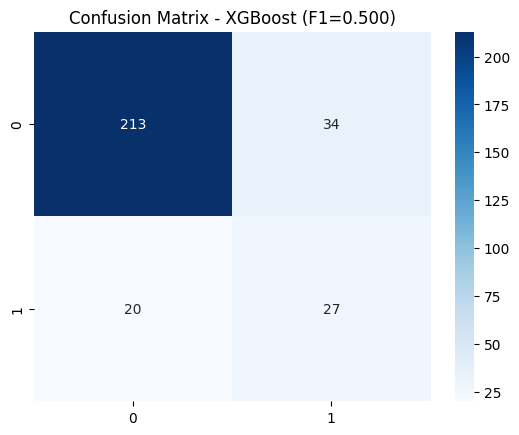

In [7]:
best_xgb = random_search.best_estimator_
y_pred = best_xgb.predict(X_test)
y_pred_proba = best_xgb.predict_proba(X_test)[:, 1]

test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Test F1: {test_f1:.4f}")
print(f"Test ROC-AUC: {test_roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - XGBoost (F1={test_f1:.3f})')
plt.show()

Вывод:
* F1 = 0.500, ROC-AUC = 0.7956.
* Матрица ошибок показывает, что модель лучше находит уволившихся (recall=0,57), но точность невысока (precision=0,44).
* Accuracy = 0,82 – высокий показатель из-за дисбаланса классов, но для задачи важнее F1 и ROC-AUC.

**8. Глобальная интерпретация модели**

**8.1 Важность признаков (встроенная)**

/tmp/ipykernel_2521/1426043625.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df.head(15), x='importance', y='feature', palette='viridis')


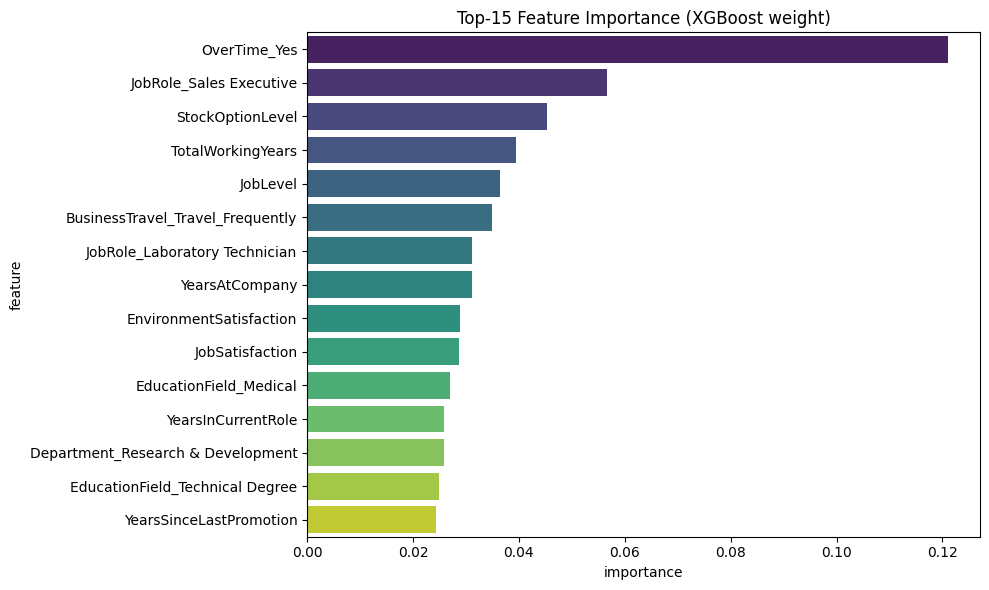

In [8]:
xgb_model = best_xgb.named_steps['classifier']
importance = xgb_model.feature_importances_
imp_df = pd.DataFrame({'feature': feature_names, 'importance': importance}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=imp_df.head(15), x='importance', y='feature', palette='viridis')
plt.title('Top-15 Feature Importance (XGBoost weight)')
plt.tight_layout()
plt.show()

**8.2 SHAP Summary Plot (глобальный)**

/tmp/ipykernel_2521/663518191.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample_processed, feature_names=feature_names, show=False)


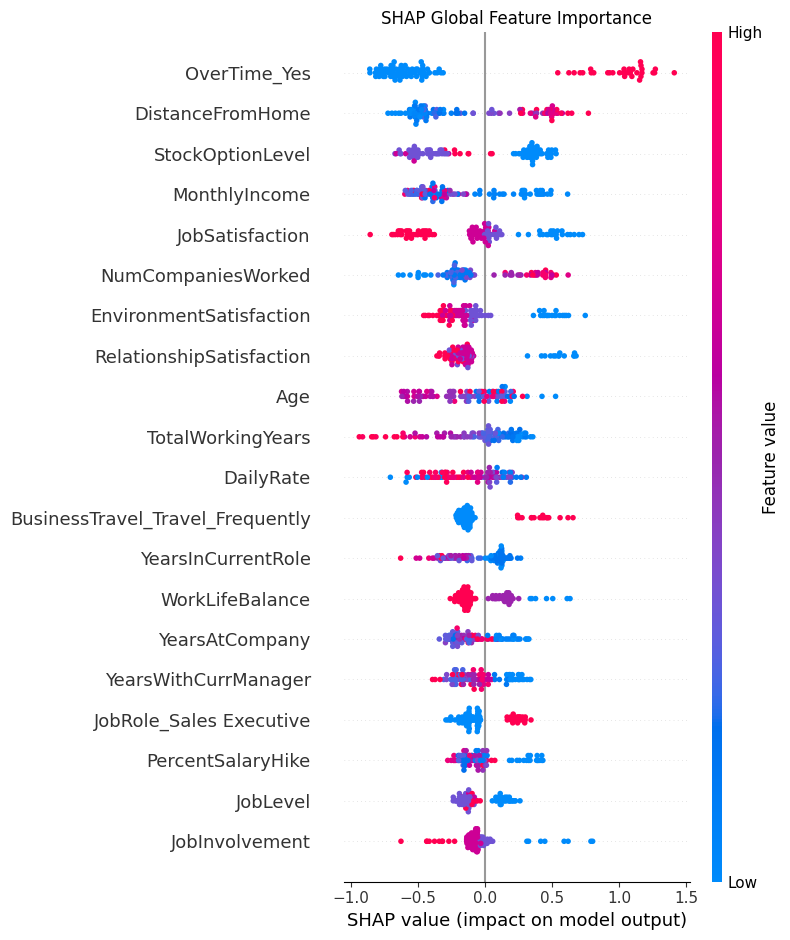

In [10]:
# Используем подвыборку для ускорения
X_test_sample = X_test.sample(min(100, len(X_test)), random_state=RANDOM_STATE)
X_test_sample_processed = preprocessor.transform(X_test_sample)

explainer = shap.TreeExplainer(best_xgb.named_steps['classifier'])
shap_values = explainer.shap_values(X_test_sample_processed)

shap.summary_plot(shap_values, X_test_sample_processed, feature_names=feature_names, show=False)
plt.title('SHAP Global Feature Importance')
plt.tight_layout()
plt.show()

Выводы:

* OverTime_Yes и BusinessTravel_Travel_Frequently – сильнейшие положительные факторы риска (переработки и частые командировки ведут к выгоранию).
* Laboratory Technician и Sales Representative – должности с повышенной текучестью.
* MaritalStatus_Single – одинокие сотрудники более мобильны.
* Модель выделяет реалистичные факторы, что подтверждает её адекватность для HR-аналитики.

**9. Локальная интерпретация предсказаний**

**9.1 Выбор примеров для анализа**

In [11]:
X_test_df = X_test.copy()
X_test_df['pred_proba'] = y_pred_proba
X_test_df['true'] = y_test.values
X_test_df['pred'] = y_pred

# Находим индексы разных типов предсказаний
tp_idx = X_test_df[(X_test_df['true']==1) & (X_test_df['pred']==1)].index[0]
tn_idx = X_test_df[(X_test_df['true']==0) & (X_test_df['pred']==0)].index[0]
fp_idx = X_test_df[(X_test_df['true']==0) & (X_test_df['pred']==1)].index[0]
fn_idx = X_test_df[(X_test_df['true']==1) & (X_test_df['pred']==0)].index[0]

print(f"True Positive  (уволился, верно): {tp_idx}")
print(f"True Negative  (остался, верно): {tn_idx}")
print(f"False Positive (ошибка): {fp_idx}")
print(f"False Negative (ошибка): {fn_idx}")

True Positive  (уволился, верно): 695
True Negative  (остался, верно): 1429
False Positive (ошибка): 381
False Negative (ошибка): 1111


**9.2 SHAP Force Plot для одного примера**

Пример True Positive (уволился)


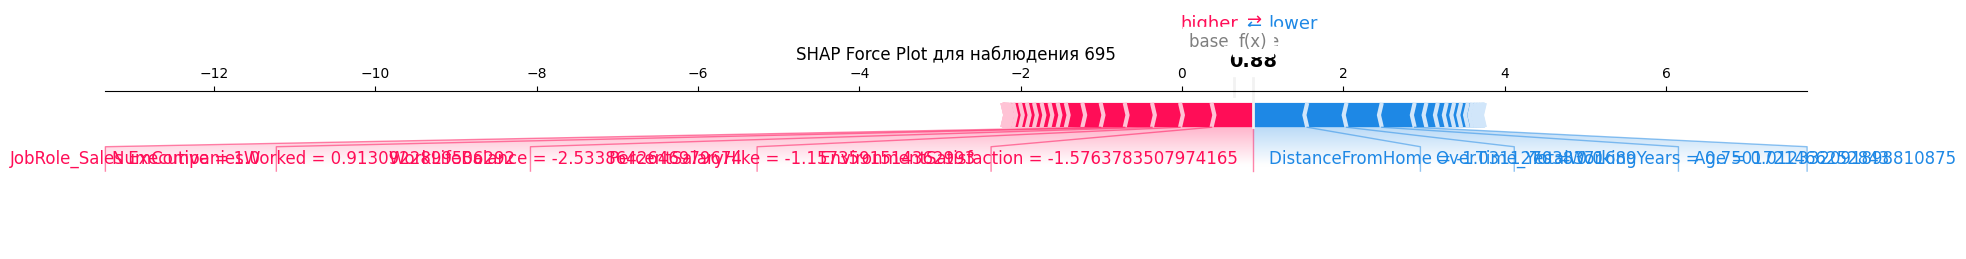

Пример False Positive (ошибка – предсказали увольнение, но сотрудник остался)


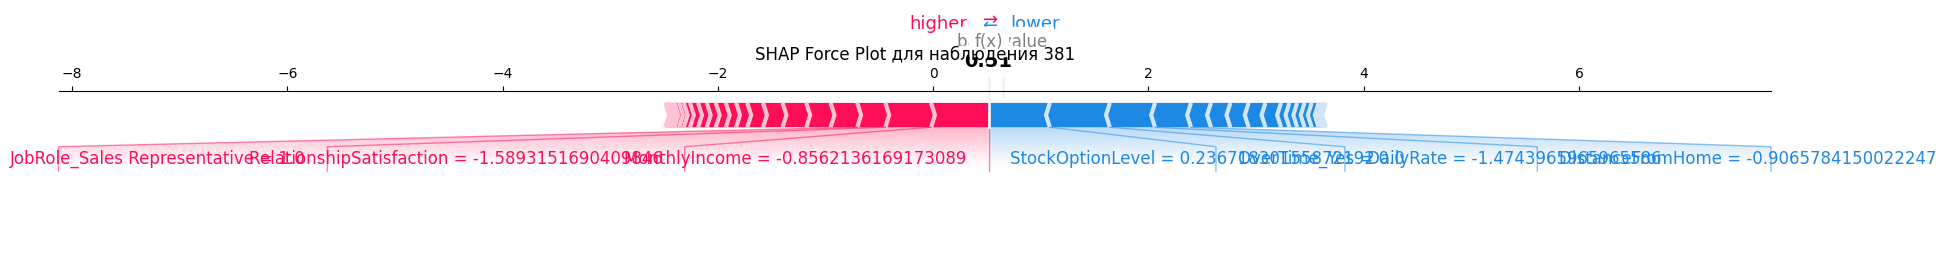

In [12]:
def plot_force(idx):
    X_obs = X_test.loc[[idx]]
    X_obs_processed = preprocessor.transform(X_obs)
    shap_values_obs = explainer.shap_values(X_obs_processed)
    shap.force_plot(explainer.expected_value, shap_values_obs, X_obs_processed,
                    feature_names=feature_names, matplotlib=True, show=False)
    plt.title(f'SHAP Force Plot для наблюдения {idx}')
    plt.tight_layout()
    plt.show()

print("Пример True Positive (уволился)")
plot_force(tp_idx)

print("Пример False Positive (ошибка – предсказали увольнение, но сотрудник остался)")
plot_force(fp_idx)

**9.3 Waterfall Plot (детализация)**

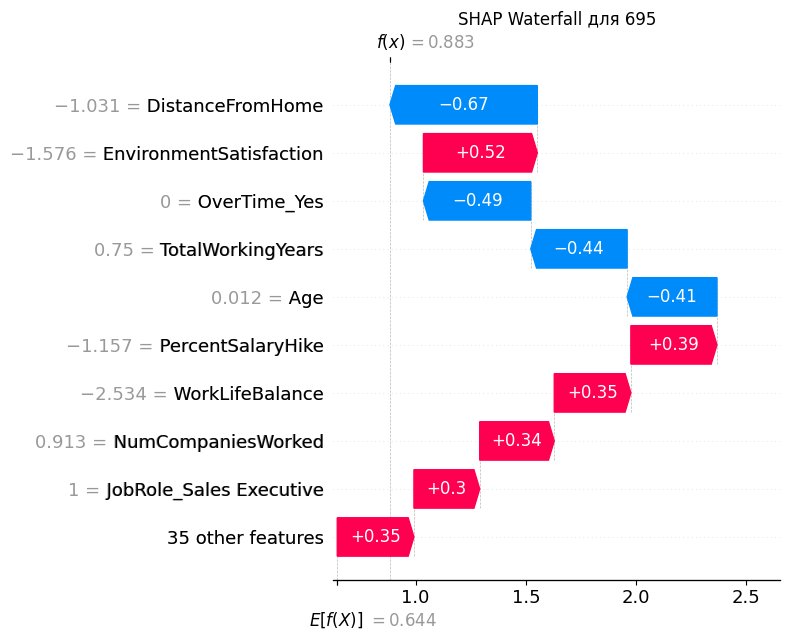

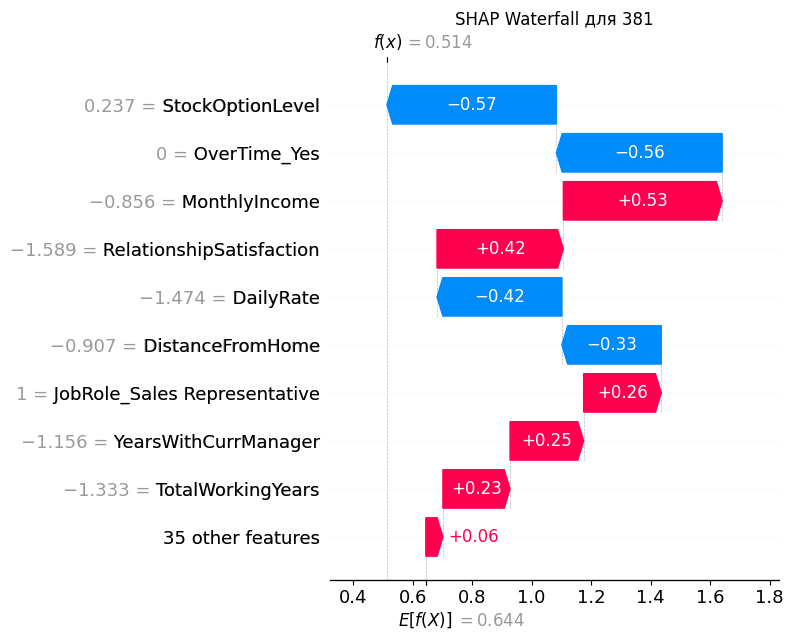

In [14]:
expected_value = explainer.expected_value
if isinstance(expected_value, list):
    expected_value = expected_value[1]

def plot_waterfall(idx):
    X_obs = X_test.loc[[idx]]
    X_obs_processed = preprocessor.transform(X_obs)
    shap_values_obs = explainer.shap_values(X_obs_processed)
    shap.waterfall_plot(shap.Explanation(values=shap_values_obs[0],
                                         base_values=expected_value,
                                         data=X_obs_processed[0],
                                         feature_names=feature_names),
                        max_display=10, show=False)
    plt.title(f'SHAP Waterfall для {idx}')
    plt.tight_layout()
    plt.show()

plot_waterfall(tp_idx)
plot_waterfall(fp_idx)

Выводы:

* Для уволившегося сотрудника главными драйверами стали OverTime_Yes и BusinessTravel_Travel_Frequently.
* В случае ошибки (False Positive) модель переоценила риск из-за сочетания невысокого стажа и переработок, хотя сотрудник в итоге остался.
* Локальные интерпретации помогают понять, почему модель принимает то или иное решение, и выявить пограничные случаи для дальнейшего улучшения.

**10. Сравнение с бейзлайнами**

          Model        F1
0         Dummy  0.000000
1        LogReg  0.540146
2  DecisionTree  0.419355
3           KNN  0.272727
4       XGBoost  0.500000


/tmp/ipykernel_2521/2788491728.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='F1', palette='Set2')


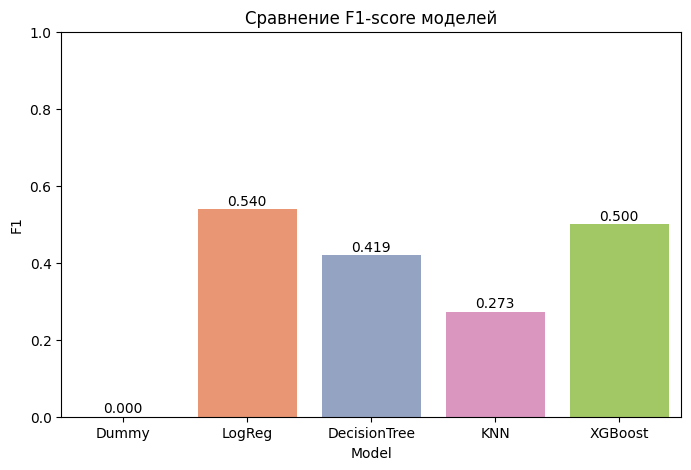

In [15]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    'Dummy': DummyClassifier(strategy='most_frequent'),
    'LogReg': LogisticRegression(max_iter=1000, class_weight='balanced', C=1, random_state=RANDOM_STATE),
    'DecisionTree': DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=3),
    'XGBoost': best_xgb
}

results = []
for name, model in models.items():
    if name != 'XGBoost':
        pipe = Pipeline([('preprocessor', preprocessor), ('clf', model)])
        pipe.fit(X_train, y_train)
        y_pred_m = pipe.predict(X_test)
    else:
        y_pred_m = model.predict(X_test)
    f1 = f1_score(y_test, y_pred_m)
    results.append((name, f1))

results_df = pd.DataFrame(results, columns=['Model', 'F1'])
print(results_df)

# Визуализация
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x='Model', y='F1', palette='Set2')
plt.title('Сравнение F1-score моделей')
plt.ylim(0, 1)
for i, row in results_df.iterrows():
    plt.text(i, row['F1']+0.01, f"{row['F1']:.3f}", ha='center')
plt.show()

Вывод:
* Dummy (most_frequent) – F1 = 0 (не предсказывает увольнения).
* Логистическая регрессия (LogReg) – F1 = 0,540 – лучший результат среди всех моделей.
* Decision Tree (max_depth=5) – F1 = 0,419.
* KNN (k=3) – F1 = 0,273.
* XGBoost – F1 = 0,500, что уступает логистической регрессии.

Хотя XGBoost проигрывает по F1, он может быть предпочтительнее в задачах, где важна интерпретируемость (SHAP) и устойчивость к переобучению. Однако по метрике F1 лучшей моделью является логистическая регрессия.



**Итоговые выводы**
* Лучшая модель по F1 – логистическая регрессия (F1 = 0,540).
* XGBoost показал F1 = 0,500, но имеет преимущества в интерпретируемости (SHAP) и может быть полезен для анализа факторов.
* Глобальная интерпретация (по XGBoost) подтверждает ключевые факторы увольнения: переработки, частые командировки, должности лабораторных техников и торговых представителей, семейное положение.
* Локальная интерпретация (SHAP) позволяет объяснить каждое предсказание и найти причины ошибок модели.

Бизнес-рекомендации:
* Сократить переработки и пересмотреть политику командировок.
* Усилить удержание для уязвимых должностей (лабораторные техники, торговые представители).
* Учитывать личные обстоятельства (например, семейное положение) при планировании карьеры.

Таким образом, для практического внедрения можно выбрать логистическую регрессию как более простую и эффективную по F1, а XGBoost использовать для углублённого анализа причин увольнений.